## ECON4060H 2021 Winter
## Quantitative Methods in Economics
### Week 2 Companion for Matrix and Linear Algebra
### Shutao Cao

## Outline
- [Vectors](#Vectors-and-vector-space)
- [Matrices](#Matrices)
- [Linear equations](#Linear-equations)

## 1 Vectors and vector space

<a id='index-1'></a>


In [145]:
x = [10.5, 5.2, 3.25, -4.0]

In [146]:
import numpy as np
x = np.array(x)
x

array([10.5 ,  5.2 ,  3.25, -4.  ])

In [147]:
print(x.size)
print(x.shape)
x.dtype

4
(4,)


dtype('float64')

In [148]:
x[0]  # 1st element

10.5

In [149]:
x[-1]  # last element

-4.0

### Two-dimensional vectors
Two 2-dimensional vectors $\mathbf{x}_1$, $\mathbf{x}_2$

In [150]:
x1 = np.array([2, 6])
x2 = np.array([4, 1])

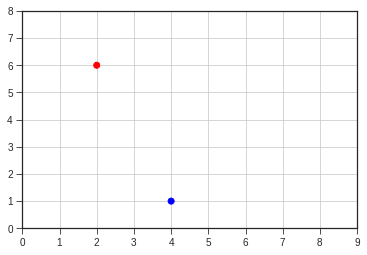

In [151]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-ticks')
x, y  = zip(x1, x2)
plt.scatter(x, y, color=["r","b"])
plt.axis([0, 9, 0, 8])
plt.grid()
plt.show()

In [152]:
def plotVector2d(vector2d, origin=[0, 0], **options):
    return plt.arrow(origin[0], origin[1], vector2d[0], vector2d[1],
              head_width=0.3, head_length=0.4, length_includes_head=True,
              **options)

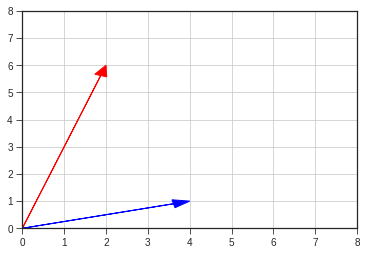

In [153]:
plotVector2d(x1, color="r")
plotVector2d(x2, color="b")
plt.axis([0, 8, 0, 8])
plt.grid()
plt.show()

Plot vector addition, $\mathbf{x}_1+\mathbf{x_2}$

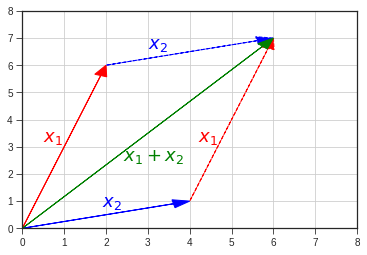

In [154]:
plotVector2d(x1, color="r")
plotVector2d(x2, color="b")
plotVector2d(x2, origin=x1, color="b", linestyle="--")
plotVector2d(x1, origin=x2, color="r", linestyle="--")
plotVector2d(x1+x2, color="g")
plt.axis([0, 8, 0, 8])
plt.text(0.5, 3.2, "$x_1$", color="r", fontsize=18)
plt.text(4.2, 3.2, "$x_1$", color="r", fontsize=18)
plt.text(1.9, 0.8, "$x_2$", color="b", fontsize=18)
plt.text(3.0, 6.6, "$x_2$", color="b", fontsize=18)
plt.text(2.4, 2.5, "$x_1+x_2$", color="g", fontsize=18)
plt.grid()
plt.show()

### 3-dimensional vectors
\begin{equation*}a = \begin{pmatrix} 2 \\ 1 \\ 8 \end{pmatrix}; \quad b= \begin{pmatrix} 5 \\ 9 \\ 2 \end{pmatrix} \end{equation*}

In [155]:
a = np.array([2, 1, 8])
b = np.array([5, 9, 2])

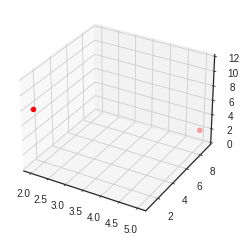

In [156]:
from mpl_toolkits.mplot3d import Axes3D
subplot3d = plt.subplot(111, projection='3d')
x, y, z = zip(a,b)
subplot3d.scatter(x, y, z, color="r")
subplot3d.set_zlim3d([0, 12])
plt.show()

To see it better the locations:

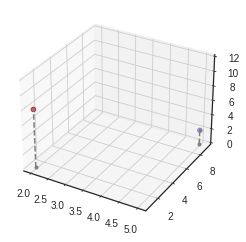

In [157]:
def plotVectors3d(ax, vectors3d, z0, **options):
    for v in vectors3d:
        x, y, z = v
        ax.plot([x,x], [y,y], [z0, z], color="gray", linestyle='--', marker=".")
    x_coords, y_coords, z_coords = zip(*vectors3d)
    ax.scatter(x_coords, y_coords, z_coords, **options)

subplot3d = plt.subplot(111, projection='3d')
subplot3d.set_zlim([0, 12])
plotVectors3d(subplot3d, [a,b], 0, color=("r","b"))
plt.show()

### Vector norm
The norm of a vector $\textbf{x}$, written as $\left \Vert \textbf{x} \right \|$, is a measure of the length of vector $\textbf{x}$. There are different definitions of norms. The **Euclidian norm** of an $n$-dimensional vector is defined as  $\left \Vert \textbf{x} \right \| = \left(\sum_{i}^n{x_i}^2\right)^{\frac{1}{2}}$

In [158]:
from numpy import linalg as LA
x = np.arange(5) - 2
LA.norm(x)

3.1622776601683795

Another operation on vectors is the inner product, we skip it

## Matrices

<a id='index-2'></a>
For example:

\begin{equation*}\mathbf{A} = \begin{bmatrix} 1 & 4  \\ 0 & -3  \\ 1 & 1 \end{bmatrix}\end{equation*}

Matrix $\mathbf{A}$ as a Python list

In [159]:
A = [
    [1., 4.],
    [0., -3.],
    [1.,1.]
]

Matrix $\mathbf{A}$ as a Numpy arrays

In [160]:
A = np.array(A)
A

array([[ 1.,  4.],
       [ 0., -3.],
       [ 1.,  1.]])

In [161]:
A.shape

(3, 2)

In [162]:
A.size

6

In [163]:
A[2,1]  # 3rd row, 2rd column

1.0

In [164]:
A[1, :]  # 2nd row vector

array([ 0., -3.])

In [165]:
A[:, 1] 

array([ 4., -3.,  1.])

In [166]:
A.T   # transpose

array([[ 1.,  0.,  1.],
       [ 4., -3.,  1.]])

In [167]:
np.diag(A)  # diagonal of A

array([ 1., -3.])

In [168]:
np.eye(3)   # 3x3 identity matrix

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### Matrix addition and multiplication
For example $A

In [169]:
B = np.array([[1,2], [3,4],[5, 6]])
B

array([[1, 2],
       [3, 4],
       [5, 6]])

In [170]:
A

array([[ 1.,  4.],
       [ 0., -3.],
       [ 1.,  1.]])

In [171]:
A + B

array([[2., 6.],
       [3., 1.],
       [6., 7.]])

In [172]:
C = B.T

In [173]:
D = np.matmul(A,C) # multiplication

In [174]:
A.dot(C)   # same as inner products of vectors

array([[  9.,  19.,  29.],
       [ -6., -12., -18.],
       [  3.,   7.,  11.]])

In [175]:
A @ C   # Another way to write inner products

array([[  9.,  19.,  29.],
       [ -6., -12., -18.],
       [  3.,   7.,  11.]])

In [176]:
A * B # is not element-wise multiplication, not matrix multiplication

array([[  1.,   8.],
       [  0., -12.],
       [  5.,   6.]])

In [177]:
D

array([[  9.,  19.,  29.],
       [ -6., -12., -18.],
       [  3.,   7.,  11.]])

In [178]:
np.matmul(D, np.eye(3))  # multiply D by identity matrix

array([[  9.,  19.,  29.],
       [ -6., -12., -18.],
       [  3.,   7.,  11.]])

### Matrix inverse
$\mathbf{A}^{-1} \mathbf{A} = \mathbf{I}$. Only square matrix can have inverse.

In [179]:
A = D + np.eye(3)
A

array([[ 10.,  19.,  29.],
       [ -6., -11., -18.],
       [  3.,   7.,  12.]])

In [180]:
A_inverse = LA.inv(A)
A_inverse

array([[-0.28571429, -1.19047619, -1.0952381 ],
       [ 0.85714286,  1.57142857,  0.28571429],
       [-0.42857143, -0.61904762,  0.19047619]])

In [181]:
np.matmul(A_inverse,A)

array([[ 1.00000000e+00,  8.88178420e-16, -1.77635684e-15],
       [ 9.99200722e-16,  1.00000000e+00, -8.88178420e-16],
       [-3.88578059e-16,  5.55111512e-17,  1.00000000e+00]])

In [182]:
D_inverse = LA.inv(D)
D_inverse

LinAlgError: Singular matrix

### Determinants
Compute the determinant of matrix $\mathbf{A}$

To get the determinant of a matrix, you can call NumPy's `det` function in the `numpy.linalg` module:

In [184]:
A

array([[ 3. ,  2. , -1. ],
       [ 1. , -2. ,  0.5],
       [ 5. ,  0.2, -2. ]])

In [185]:
LA.det(A)

10.5

A matrix is singular (has not inverse) if it's determinant is zero

In [186]:
D

array([[  9.,  19.,  29.],
       [ -6., -12., -18.],
       [  3.,   7.,  11.]])

$\mathbf{D}$ is singular

In [187]:
LA.det(D)

0.0

### Eigenvectors and eigenvalues
If $\mathbf{A x} = \lambda \mathbf{x}$,  then $\lambda$ is the **eigenvalue** associated to the eigenvector $\mathbf{x}$.

In [188]:
A

array([[ 3. ,  2. , -1. ],
       [ 1. , -2. ,  0.5],
       [ 5. ,  0.2, -2. ]])

In [189]:
eigenvalues, eigenvectors = LA.eig(A)
eigenvalues # returns all eigenvalues of A

array([ 2.57138457+0.j        , -1.78569229+0.94588914j,
       -1.78569229-0.94588914j])

In [190]:
eigenvectors # [v0, v1, …]

array([[0.65306756+0.j        , 0.02515471+0.17698846j,
        0.02515471-0.17698846j],
       [0.22204973+0.j        , 0.28037062-0.41160937j,
        0.28037062+0.41160937j],
       [0.72401428+0.j        , 0.84853542+0.j        ,
        0.84853542-0.j        ]])

## Linear equations

<a id='index-3'></a>

Solving a system of linear equations:
\begin{align*}3 x_0 + 2 x_1 - x_2 = 9 \\ x_0 - 2 x_1 + 0.5x_2 = 2 \\  5 x_0 +0.2x_1 - 2x_2 = 10 \end{align*}
In matrix, $A x = b$

In [191]:
from numpy import linalg
A = np.array([[3, 2, -1], [1,-2, 0.5], [5,0.2,-2]])
b = np.array([9,2,10])
x = np.linalg.solve(A, b)
print('x=',x)

x= [3.11428571 1.28571429 2.91428571]
